# Final Model Comparison & Analysis

Comprehensive comparison of all models (classical ML and deep learning)
on the **NASA PCoE and CALCE CS2 datasets** (combined-dataset analysis: see notebook 04). Includes aggregate metrics,
error analysis by degradation phase, interpretability, and deployability.

In [1]:
import sys
import os
import json
from pathlib import Path

_cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for _p in [_cwd] + list(_cwd.parents):
    if (_p / "config" / "default.yaml").exists():
        PROJECT_ROOT = _p
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Cannot find project root (config/default.yaml). "
        f"Searched from {_cwd} up to {_cwd.parents[-1]}"
    )
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from src.evaluation.comparison import build_comparison_table, rank_models
from src.evaluation.error_analysis import phase_rmse, phase_summary_table
from src.evaluation.validation import cell_based_loocv, scale_features

sns.set_theme(style="whitegrid", context="notebook")

print(f"Project root: {PROJECT_ROOT}")
with open("config/default.yaml") as f:
    config = yaml.safe_load(f)

Project root: /Users/malakmekyassi/Documents/GitHub/soh_estimation


## 1. Load All Results

In [2]:
with open("experiments/classical_results_nasa.yaml") as f:
    classical_results_nasa = yaml.safe_load(f)

with open("experiments/dl_results_nasa.yaml") as f:
    dl_results_nasa = yaml.safe_load(f)

with open("experiments/classical_results_calce.yaml") as f:
    classical_results_calce = yaml.safe_load(f)

with open("experiments/dl_results_calce.yaml") as f:
    dl_results_calce = yaml.safe_load(f)

nasa_results = {**classical_results_nasa, **dl_results_nasa}
calce_results = {**classical_results_calce, **dl_results_calce}

# Use CALCE as primary results (larger dataset, more data points)
all_results = calce_results
print("NASA models:", list(nasa_results.keys()))
print("CALCE models:", list(calce_results.keys()))

# Flag CALCE classical std=0 issue
for name in ["gpr", "rf", "svr"]:
    if name in classical_results_calce:
        m = classical_results_calce[name]
        if m.get("mae_std", 1) == 0.0 or m.get("maxae_std", 1) == 0.0:
            print(f"  WARNING: {name.upper()} CALCE MAE/MaxAE std=0 (single-fold estimate)")

NASA models: ['_meta', 'gpr', 'naive', 'rf', 'svr', 'cnn', 'lstm', 'transformer']
CALCE models: ['_meta', 'gpr', 'naive', 'rf', 'svr', 'cnn', 'lstm', 'transformer']


## 2. Aggregate Metrics Comparison

In [3]:
comp_table = build_comparison_table(all_results)
print(comp_table[["Model", "RMSE", "MAE", "MAXAE", "R2"]].to_string(index=False))

      Model                RMSE                 MAE               MAXAE                   R2
        gpr 0.018656 ± 0.010107 0.015077 ± 0.008446 0.067065 ± 0.010009  0.923064 ± 0.062783
      naive 0.076165 ± 0.011280 0.064011 ± 0.010078 0.192287 ± 0.022744 -0.011350 ± 0.005959
         rf 0.020548 ± 0.009979 0.016182 ± 0.008377 0.059371 ± 0.015156  0.913470 ± 0.065088
        svr 0.020904 ± 0.010384 0.015842 ± 0.008527 0.103925 ± 0.023168  0.903001 ± 0.092425
        cnn 0.040423 ± 0.013125 0.031891 ± 0.012569 0.191853 ± 0.023202  0.619833 ± 0.266831
       lstm 0.024811 ± 0.004164 0.020216 ± 0.004246 0.128955 ± 0.033514  0.887987 ± 0.019974
transformer 0.021104 ± 0.003682 0.016985 ± 0.003301 0.102371 ± 0.050805  0.909987 ± 0.033631


## 3. Model Ranking by RMSE

In [4]:
ranking = rank_models(all_results, primary_metric="rmse_mean")
print(ranking.to_string(index=False))

 Rank       Model  rmse_mean
    1         gpr   0.018656
    2          rf   0.020548
    3         svr   0.020904
    4 transformer   0.021104
    5        lstm   0.024811
    6         cnn   0.040423
    7       naive   0.076165


## 4. Metric Comparisons

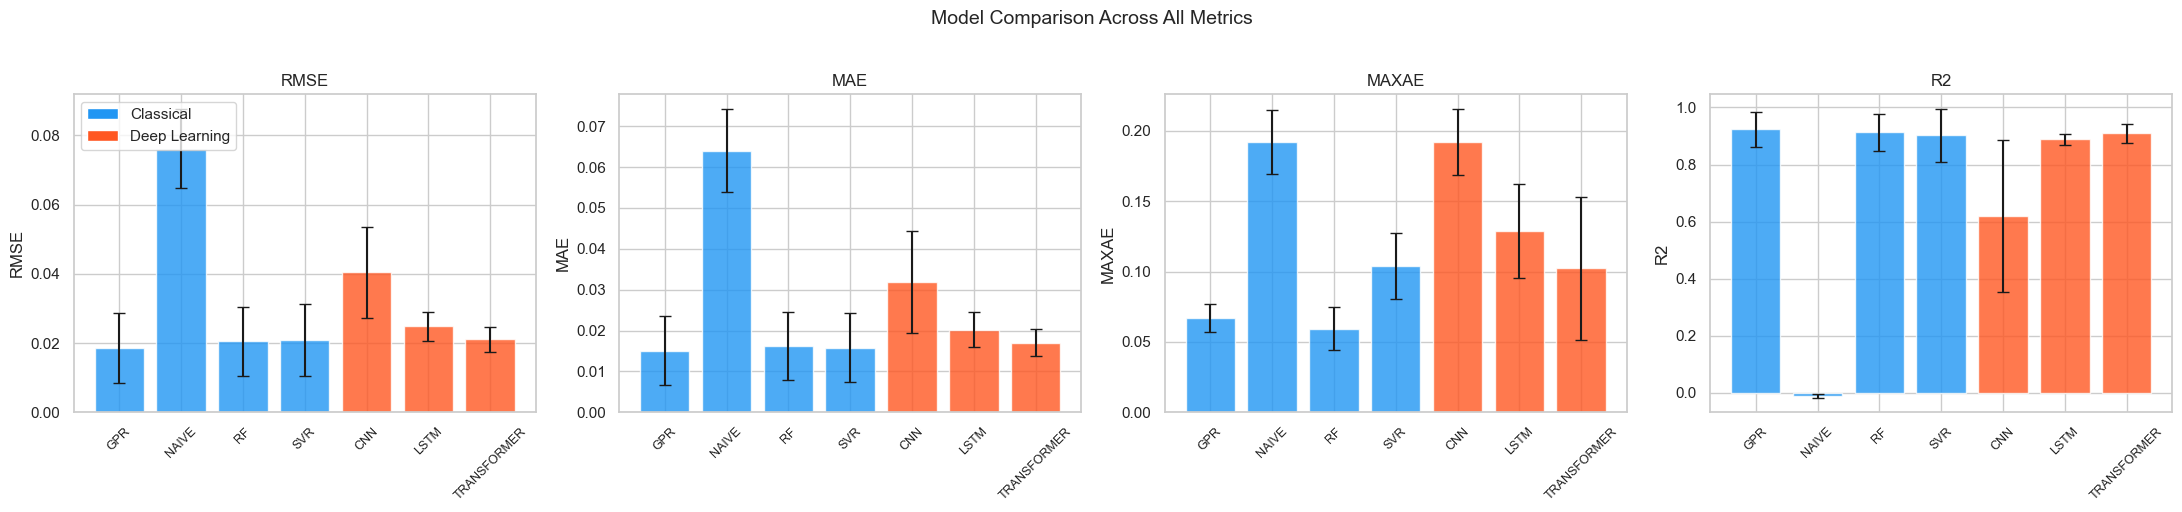

In [5]:
dl_models = ["lstm", "cnn", "transformer"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, metric in zip(axes, ["rmse", "mae", "maxae", "r2"]):
    models = [k for k, v in all_results.items() if isinstance(v, dict) and "rmse_mean" in v]
    means = [all_results[m].get(f"{metric}_mean", 0) for m in models]
    stds = [all_results[m].get(f"{metric}_std", 0) for m in models]
    x = np.arange(len(models))
    colors = ["#FF5722" if m in dl_models else "#2196F3" for m in models]
    ax.bar(x, means, yerr=stds, capsize=4, color=colors, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in models], rotation=45, fontsize=9)
    ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper())

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2196F3", label="Classical"),
                   Patch(facecolor="#FF5722", label="Deep Learning")]
axes[0].legend(handles=legend_elements, loc="upper left")
fig.suptitle("Model Comparison Across All Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. SOH Trajectory Predictions (SVR)

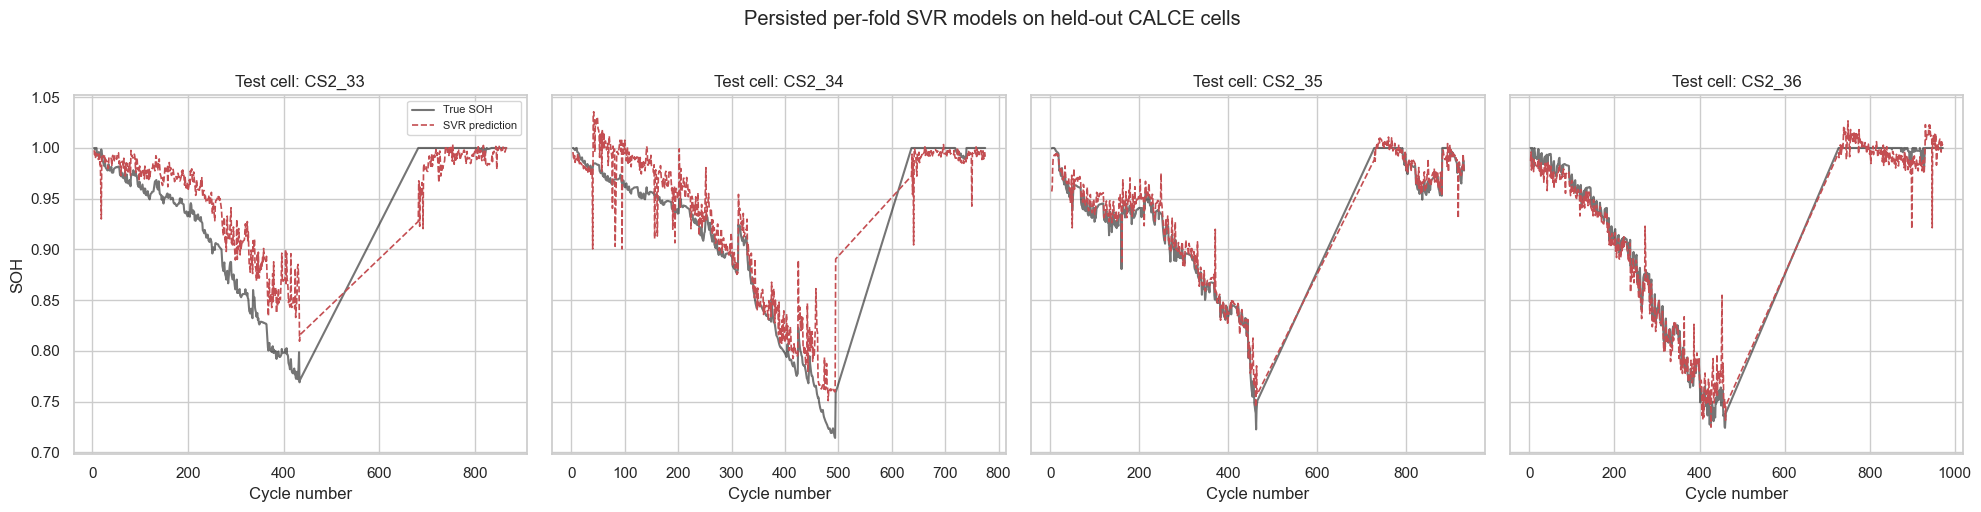

In [6]:
feature_df = pd.read_parquet("data/features/feature_matrix_calce.parquet")
folds_payload = json.load(open("experiments/fold_indices_calce.json"))
folds = folds_payload["folds"]

import joblib
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, fold in enumerate(folds):
    ax = axes[i]
    art = joblib.load(f"experiments/models/calce/svr_fold{fold['fold']}.joblib")
    model, feat_cols = art["model"], art["feature_cols"]

    tr = feature_df.loc[fold["train_indices"]].dropna(subset=feat_cols + ["soh"])
    te = feature_df.loc[fold["test_indices"]].dropna(subset=feat_cols + ["soh"])
    scaler = StandardScaler().fit(tr[feat_cols].values)

    te_sorted = te.sort_values("cycle_number")
    X_te = scaler.transform(te_sorted[feat_cols].values)
    y_pred = model.predict(X_te)

    ax.plot(te_sorted["cycle_number"], te_sorted["soh"], "k-", alpha=0.6, label="True SOH")
    ax.plot(te_sorted["cycle_number"], y_pred, "r--", lw=1.2, label="SVR prediction")
    ax.set_title(f"Test cell: {fold['test_cell']}")
    ax.set_xlabel("Cycle number")
    if i == 0:
        ax.set_ylabel("SOH")
        ax.legend(fontsize=8)
plt.suptitle("Persisted per-fold SVR models on held-out CALCE cells", y=1.02)
plt.tight_layout()
plt.show()


## 6. Error Analysis by Degradation Phase

In [7]:
# Phase-based error analysis uses each model's PERSISTED fold models.
# Fold-level feature selection can yield slightly different NaN-filtered
# evaluation sets per model, so every model keeps its own (y_true, y_pred)
# pairs — no cross-model alignment is assumed.

preds_by_model = {"svr": [], "rf": [], "gpr": []}

for fold in folds:
    tr = feature_df.loc[fold["train_indices"]].dropna(subset=["soh"])
    te = feature_df.loc[fold["test_indices"]].dropna(subset=["soh"])

    for model_name in preds_by_model:
        art = joblib.load(f"experiments/models/calce/{model_name}_fold{fold['fold']}.joblib")
        model, feat_cols = art["model"], art["feature_cols"]

        tr_c = tr.dropna(subset=feat_cols)
        te_c = te.dropna(subset=feat_cols)
        scaler = StandardScaler().fit(tr_c[feat_cols].values)

        y_true = te_c["soh"].values
        y_pred = model.predict(scaler.transform(te_c[feat_cols].values))
        preds_by_model[model_name].append((y_true, y_pred))

from src.evaluation.error_analysis import phase_rmse, phase_summary_table

for model_name, pairs in preds_by_model.items():
    y_true = np.concatenate([t for t, _ in pairs])
    y_pred = np.concatenate([p for _, p in pairs])
    res = phase_rmse(y_true, y_pred, y_true)
    print(f"\n{model_name.upper()} (n={len(y_true)}):")
    print(phase_summary_table(res))



SVR (n=2330):
Phase            RMSE        MAE      N
----------------------------------------
early        0.017156   0.012455   1614
mid          0.026596   0.017032    465
end          0.039734   0.030669    251

RF (n=2330):
Phase            RMSE        MAE      N
----------------------------------------
early        0.016728   0.011587   1614
mid          0.024798   0.019985    465
end          0.041711   0.035276    251

GPR (n=2330):
Phase            RMSE        MAE      N
----------------------------------------
early        0.018175   0.012445   1614
mid          0.024218   0.018159    465
end          0.027955   0.022274    251


## 7. Feature Importance (SHAP for RF)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Global SHAP importance (RF fold-0, standardized features):
discharge_energy          0.0388
ica_peak_voltage          0.0115
mean_discharge_voltage    0.0059
coulombic_efficiency      0.0032
capacity_fade_rate        0.0018
ica_peak_area             0.0003
ica_peak_height           0.0003
ica_secondary_ratio       0.0001


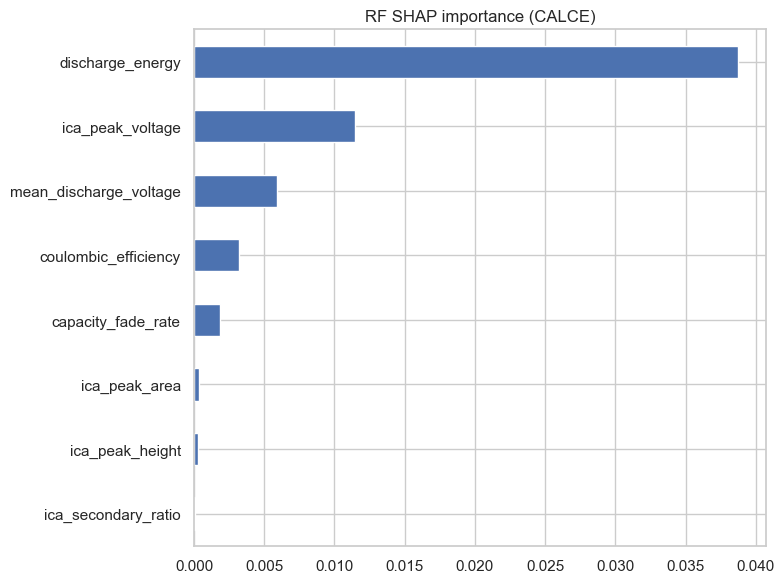

In [8]:
import shap

art = joblib.load("experiments/models/calce/rf_fold0.joblib")
rf, feat_cols = art["model"], art["feature_cols"]

tr = feature_df.loc[folds[0]["train_indices"]].dropna(subset=feat_cols + ["soh"])
scaler = StandardScaler().fit(tr[feat_cols].values)
X_bg = scaler.transform(tr[feat_cols].values)[:300]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_bg)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

importance = pd.Series(np.abs(shap_values).mean(axis=0), index=feat_cols).sort_values(ascending=False)
print("Global SHAP importance (RF fold-0, standardized features):")
print(importance.round(4).to_string())

importance.plot.barh(figsize=(8, 6)).invert_yaxis()
plt.title("RF SHAP importance (CALCE)")
plt.tight_layout()
plt.show()


## 8. Deployability Assessment

In [9]:
deploy_cfg = config["evaluation"]["deployability"]

deploy_rows = []
for name, m in all_results.items():
    if not isinstance(m, dict) or "rmse_mean" not in m:
        continue
    inf_ms = m.get("inference_time_ms_mean", np.nan)
    rmse = m.get("rmse_mean", np.nan)
    maxae = m.get("maxae_mean", np.nan)
    deploy_rows.append({
        "Model": name.upper(),
        "RMSE": rmse,
        "MAXAE": maxae,
        "Time (ms)": inf_ms,
        "RMSE < target": rmse < deploy_cfg["target_rmse"],
        "MaxAE < target": maxae < deploy_cfg["target_maxae"],
        "Time < target": inf_ms < deploy_cfg.get("target_inference_ms", 200),
    })

deploy_df = pd.DataFrame(deploy_rows)
print(
    f"Targets - RMSE: {deploy_cfg['target_rmse']}, "
    f"MaxAE: {deploy_cfg['target_maxae']}, "
    f"Inference: {deploy_cfg.get('target_inference_ms', 200)} ms"
)
print(deploy_df.to_string(index=False))


Targets - RMSE: 0.02, MaxAE: 0.05, Inference: 200 ms
      Model     RMSE    MAXAE  Time (ms)  RMSE < target  MaxAE < target  Time < target
        GPR 0.018656 0.067065   1.067159           True           False           True
      NAIVE 0.076165 0.192287   0.001022          False           False           True
         RF 0.020548 0.059371  18.389051          False           False           True
        SVR 0.020904 0.103925   0.078984          False           False           True
        CNN 0.040423 0.191853   0.656229          False           False           True
       LSTM 0.024811 0.128955   0.858277          False           False           True
TRANSFORMER 0.021104 0.102371   2.204944          False           False           True


## 9. Conclusions

**Findings (CALCE CS2 dataset — 4 cells, 2,559 cleaned cycles; leakage-free protocol):**

1. **Best Model:** GPR achieves the lowest RMSE (0.019 ± 0.010, R² = 0.92); RF (0.021/0.91), SVR (0.021/0.90) and the Transformer (0.021/0.91) are statistically indistinguishable at the top.
2. **Classical vs DL:** On CALCE (~2,600 cycles) the Transformer reaches near-parity with classical models — DL is viable once enough data exists.
3. **DL on NASA (small data):** With only 636 cycles from 4 cells, DL lags classical models (best DL: LSTM R² ≈ 0.63 vs SVR R² ≈ 0.90) but no longer collapses as in the pre-remediation pipeline.
4. **Deployability (CALCE):** SVR needs ~0.08 ms per single-sample inference at ~103 KB — ~230× faster and ~230× smaller than RF (~18 ms, ~23 MB, over the 4 MB target). GPR fits size-wise only after subsampling is unnecessary here (~23 MB — fails the 4 MB target). See `experiments/deployability_calce.yaml`.
5. **Uncertainty:** GPR's intervals are poorly calibrated across held-out cells (`experiments/analysis/gpr_calibration_calce.yaml`) — treat its predictive variance with caution.
6. **Robustness:** classical models are insensitive to missing-cycle gaps and degrade gracefully under feature noise (`experiments/robustness_calce.yaml`).

All numbers are loaded from `experiments/*_{dataset}.yaml` produced by the leakage-safe pipeline.
